
# Mock Compositional Data + Lin GP Regression 

In [1]:
import sys
from pathlib import Path

project_root = Path(r"c:\Users\floki\PycharmProjects\dash-azure-prototype")
src_root = project_root / "src"
for p in (project_root, src_root):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
artifact_dir = project_root / "ml" / "models" / "artifacts" / "demo_lin"
artifact_dir.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [3]:
from ml.scripts.plotting import (
    plot_true_vs_predicted,
)
from ml.scripts.trainers import GPRTrainer
from ml.scripts.log import init_ml_logger, log_data_summary
from worker.models import LIN
from worker.models.specs import ModelConfig, PreprocessConfig, AuxilaryData
from worker.models.io_utils import ArtifactIO
from worker.torch_utils import get_default_device

In [4]:
# load demo data for testing, geology data with compositional features
data_path =  project_root / "ml" / "data" / "examples" / "sediments_data.csv"
df = pd.read_csv(data_path)
df = df.rename(columns=lambda c: str(c).strip())
df = df[[k for k in df.keys() if "X" in k or ("Y" in k and int(k[1:]) <= 10)]]
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9,Y10
0,50.878306,1.585700,15.139037,9.430002,0.158689,7.377606,11.991212,2.614107,0.481218,0.222283,...,100.024960,62.401831,0.380,95.000000,2.480362,1.381603,8.698865,64.113000,254.781000,306.508000
1,50.946523,1.538539,15.646498,8.674868,0.167713,7.351243,12.372583,2.601054,0.482049,0.218930,...,100.000000,64.256757,NaN,NaN,2.463131,1.332379,8.022467,69.894193,241.946713,277.496404
2,50.914880,1.529394,15.190011,9.153952,0.157481,7.495558,12.170296,2.544098,0.472642,0.229280,...,99.984392,63.464847,0.347,86.952381,2.438507,1.368964,8.576773,73.000000,280.000000,270.000000
3,51.038205,1.462966,15.420000,9.085860,0.160000,7.583125,12.280000,2.461189,0.417908,0.221035,...,100.265688,63.906136,0.371,102.666667,2.377320,1.335617,8.605845,77.000000,283.000000,277.000000
4,50.612286,1.409480,15.407908,8.916492,0.180880,7.795704,12.386817,2.507115,0.440833,0.209050,...,99.879764,64.970813,NaN,NaN,2.463667,1.348711,8.677588,73.010640,285.408170,271.692840


In [5]:
# train test split
feature_cols = [k for k in df.keys() if "X" in k]
target_cols = [k for k in df.keys() if "Y" in k]

# row_sums = df[feature_cols].sum(axis=1)
# df[feature_cols] = df[feature_cols].div(row_sums.replace(0, pd.NA), axis=0)
df[feature_cols] /= 100

df = df.dropna(subset=feature_cols, how="any", axis=0)
df = df.dropna(subset=target_cols, how="all", axis=0)
df = df.drop_duplicates(subset=feature_cols, keep="first", ignore_index=True)
df = df.reset_index(drop=True)

X = df[feature_cols].to_numpy()
y = df[target_cols].to_numpy()

train_x, test_x, train_y, test_y = train_test_split(
    X, y, test_size=0.1, random_state=1, shuffle=True,
)

train_x_raw = train_x.copy()
test_x_raw = test_x.copy()
train_y_raw = train_y.copy()
test_y_raw = test_y.copy()

In [6]:
# drop features without variance
var_x = VarianceThreshold(threshold=1e-6)
train_x = var_x.fit_transform(train_x)
test_x = var_x.transform(test_x)
train_x_raw = var_x.transform(train_x_raw)
test_x_raw = var_x.transform(test_x_raw)
kept_mask_x = var_x.get_support()
feature_cols = [c for c, keep in zip(feature_cols, kept_mask_x) if keep]

In [7]:
# drop targets without variance
var_y = VarianceThreshold(threshold=1e-6)
train_y = var_y.fit_transform(train_y)
test_y = var_y.transform(test_y)
train_y_raw = var_y.transform(train_y_raw)
test_y_raw = var_y.transform(test_y_raw)
kept_mask_y = var_y.get_support()
target_cols = [c for c, keep in zip(target_cols, kept_mask_y) if keep]

In [8]:
# feature scaling
scaler_x = StandardScaler()
train_x = scaler_x.fit_transform(train_x)
test_x = scaler_x.transform(test_x)

In [9]:
# target scaling
scaler_y = StandardScaler()
train_y = scaler_y.fit_transform(train_y)
test_y = scaler_y.transform(test_y)

In [10]:
# setup model
prep = PreprocessConfig(scaler_x=scaler_x, scaler_y=scaler_y)
noise_rank = 1
covar_rank = 1
spec = ModelConfig(
    model_type="lin",
    features=feature_cols,
    targets=target_cols,
    requires_aux=True,
    model_kwargs={"covar_rank": covar_rank, "noise_rank": noise_rank},
)
aux = AuxilaryData(train_x=train_x, train_y=train_y)
model = LIN(spec, prep, aux)

In [11]:
# conduct training
device = get_default_device()
print(f"Running on {str(device)}")
trainer = GPRTrainer(model, device=device, lr=0.05)
metrics = trainer.train(train_x, train_y, epochs=500)

Running on cuda


GP training:   0%|          | 0/500 [00:00<?, ?it/s]

In [12]:
# check if storing / loading of artifacts works
ArtifactIO.save(artifact_dir, model=model, spec=spec, prep=prep, aux=aux)
loaded_model = ArtifactIO.load(artifact_dir, device=device)

In [13]:
# test predictions on test set
preds = loaded_model.predict(test_x_raw, device=device, return_std=True)
pred_mean = preds.get('mean')
pred_std = preds.get('std')

preds_train = loaded_model.predict(train_x_raw, device=device, return_std=True)
pred_mean_train = preds_train.get('mean')
pred_std_train = preds_train.get('std')

In [14]:
logger, _ = init_ml_logger(artifact_dir, "training")
if logger is not None:
    logger.info("Train time (s): %.3f", trainer.duration)
    log_data_summary(
        logger,
        train_y_raw,
        y_pred=pred_mean_train,
        y_std=pred_std_train,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Train",
    )
    log_data_summary(
        logger,
        test_y_raw,
        y_pred=pred_mean,
        y_std=pred_std,
        feature_cols=feature_cols,
        target_cols=target_cols,
        phase="Test",
    )

2026-04-03 09:47:16,305 | INFO | Train time (s): 19.428
2026-04-03 09:47:16,308 | INFO | Train: n_obs=128 n_features=8 n_targets=10 non_nan_targets=785
2026-04-03 09:47:16,309 | INFO | Train metrics per target:
2026-04-03 09:47:16,311 | INFO |   Y1 | R2=0.9872 MAPE=0.0003 PICP(95%)=1.0000
2026-04-03 09:47:16,313 | INFO |   Y2 | R2=0.9990 MAPE=0.0012 PICP(95%)=1.0000
2026-04-03 09:47:16,315 | INFO |   Y3 | R2=0.9419 MAPE=0.0394 PICP(95%)=0.9167
2026-04-03 09:47:16,318 | INFO |   Y4 | R2=0.3441 MAPE=0.2266 PICP(95%)=0.9429
2026-04-03 09:47:16,319 | INFO |   Y5 | R2=0.9974 MAPE=0.0017 PICP(95%)=1.0000
2026-04-03 09:47:16,321 | INFO |   Y6 | R2=0.9726 MAPE=0.0097 PICP(95%)=0.9740
2026-04-03 09:47:16,323 | INFO |   Y7 | R2=0.9858 MAPE=0.0034 PICP(95%)=0.9870
2026-04-03 09:47:16,324 | INFO |   Y8 | R2=0.8260 MAPE=0.1189 PICP(95%)=0.9020
2026-04-03 09:47:16,326 | INFO |   Y9 | R2=0.7692 MAPE=0.2299 PICP(95%)=0.9038
2026-04-03 09:47:16,328 | INFO |   Y10 | R2=0.8837 MAPE=0.0195 PICP(95%)=0.750

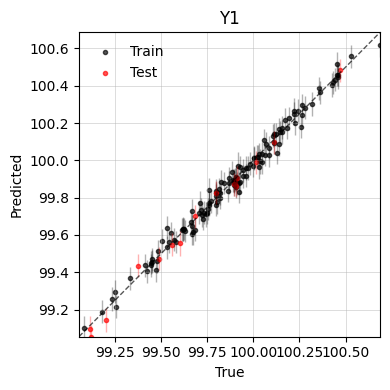

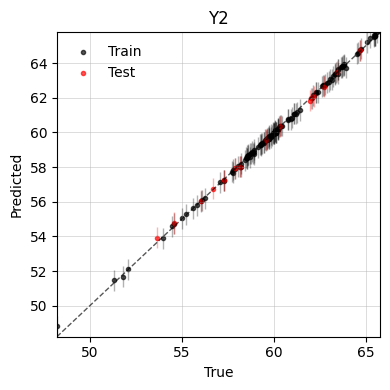

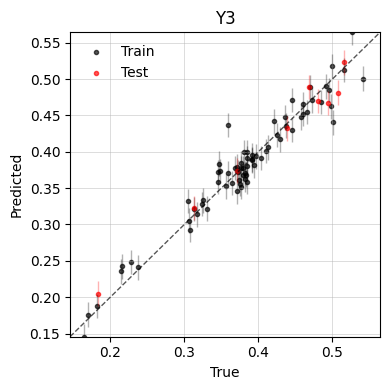

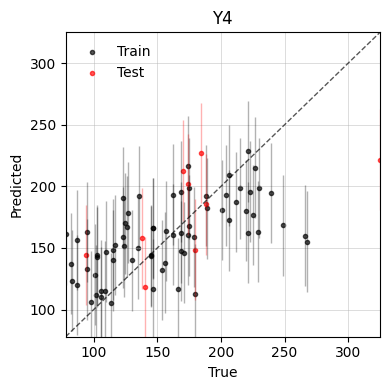

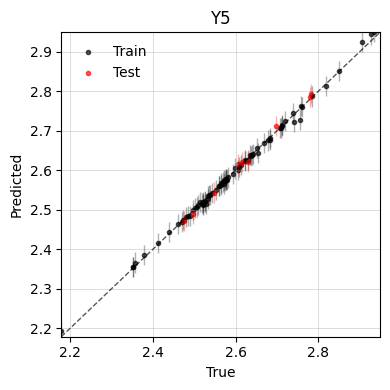

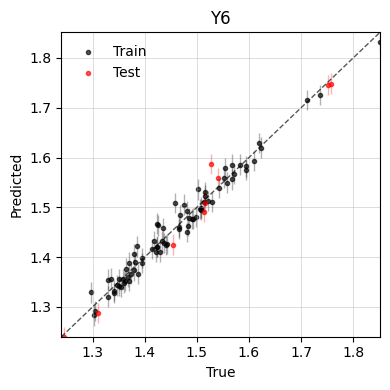

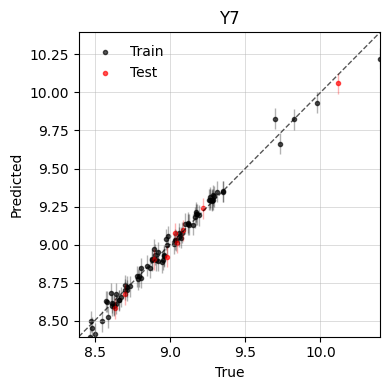

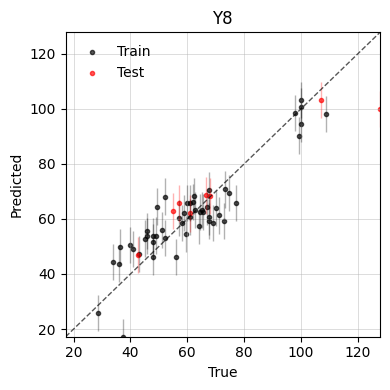

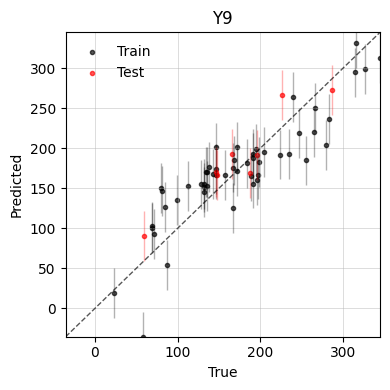

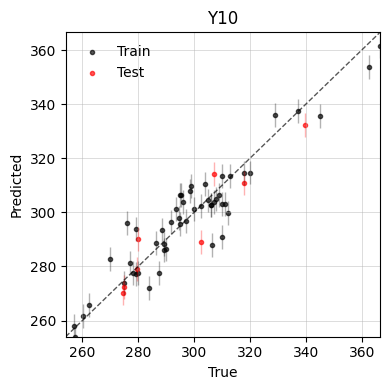

In [15]:
plots_dir = artifact_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plot_true_vs_predicted(
    train_y_raw,
    pred_mean_train,
    y_std=pred_std_train,
    y_true_test=test_y_raw,
    y_pred_test=pred_mean,
    y_std_test=pred_std,
    target_cols=target_cols,
    show_std=pred_std is not None or pred_std_train is not None,
    filepath=plots_dir / "results",
)

In [16]:
# Outlier + summary export (unscaled)
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import r2_score
from ml.scripts.metrics import mape, picp
from ml.scripts.outliers import build_outliers_dataframe, save_outliers_csv

reports_dir = artifact_dir / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

_pred_std_train = pred_std_train if "pred_std_train" in globals() else None
_pred_std = pred_std if "pred_std" in globals() else None

def _metrics_table(y_true, y_pred, y_std, target_cols, coverage=0.95):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = None if y_pred is None else np.asarray(y_pred, dtype=float)
    y_std = None if y_std is None else np.asarray(y_std, dtype=float)

    if y_true.ndim == 1:
        y_true = y_true.reshape(-1, 1)
    if y_pred is not None and y_pred.ndim == 1:
        y_pred = y_pred.reshape(-1, 1)
    if y_std is not None and y_std.ndim == 1:
        y_std = y_std.reshape(-1, 1)

    labels = target_cols or [f"y{i}" for i in range(y_true.shape[1])]
    rows = []
    for i, name in enumerate(labels):
        yt = y_true[:, i]
        yp = y_pred[:, i] if y_pred is not None else None
        ys = y_std[:, i] if y_std is not None else None

        mask = ~np.isnan(yt)
        if yp is not None:
            mask &= ~np.isnan(yp)
        if ys is not None:
            mask &= ~np.isnan(ys)

        yt = yt[mask]
        yp = yp[mask] if yp is not None else None
        ys = ys[mask] if ys is not None else None

        r2_val = np.nan
        if yp is not None and yt.size >= 2:
            try:
                r2_val = r2_score(yt, yp)
            except Exception:
                pass

        mape_val = np.nan
        if yp is not None and yt.size > 0:
            try:
                mape_val = float(mape(
                    yt.reshape(-1, 1),
                    y_pred=yp.reshape(-1, 1),
                    multioutput="raw_values",
                )[0])
            except Exception:
                pass

        picp_val = np.nan
        if yp is not None and ys is not None and yt.size > 0:
            try:
                picp_val = float(picp(
                    yt.reshape(-1, 1),
                    y_pred=yp.reshape(-1, 1),
                    y_std=ys.reshape(-1, 1),
                    multioutput="raw_values",
                )[0])
            except Exception:
                pass

        rows.append({"target": name, "r2": r2_val, "mape": mape_val, "picp": picp_val})

    return pd.DataFrame(rows)

metrics_train = _metrics_table(train_y_raw, pred_mean_train, _pred_std_train, target_cols)
metrics_train["phase"] = "Train"
metrics_test = _metrics_table(test_y_raw, pred_mean, _pred_std, target_cols)
metrics_test["phase"] = "Test"
metrics_df = pd.concat([metrics_train, metrics_test], ignore_index=True)
metrics_df.to_csv(reports_dir / "metrics_summary.csv", index=False)

summary_train = build_outliers_dataframe(
    train_x_raw,
    train_y_raw,
    y_pred=pred_mean_train,
    y_std=_pred_std_train,
    feature_cols=feature_cols,
    target_cols=target_cols,
    phase="Train",
    include_all=True,
)
summary_test = build_outliers_dataframe(
    test_x_raw,
    test_y_raw,
    y_pred=pred_mean,
    y_std=_pred_std,
    feature_cols=feature_cols,
    target_cols=target_cols,
    phase="Test",
    include_all=True,
)
summary_df = pd.concat([summary_train, summary_test], ignore_index=True)
summary_df.to_csv(reports_dir / "predictions_summary.csv", index=False)

if "outlier_any" in summary_df.columns:
    outliers_df = summary_df[summary_df["outlier_any"]].copy()
else:
    outliers_df = summary_df.head(0).copy()

save_outliers_csv(reports_dir / "outliers.csv", outliers_df)

print(f"Summary rows: {len(summary_df)} | Outliers: {len(outliers_df)}")
display(metrics_df.head())
display(outliers_df.head())


Summary rows: 143 | Outliers: 25


,target,r2,mape,picp,phase
0,Y1,0.987197,0.000273,1.000000,Train
1,Y2,0.998970,0.001212,1.000000,Train
2,Y3,0.941876,0.039445,0.916667,Train
3,Y4,0.344111,0.226590,0.942857,Train
4,Y5,0.997408,0.001687,1.000000,Train


,row_index,phase,X1,X2,X3,X4,X6,X7,X8,X9,...,outside_Y3,outside_Y4,outside_Y5,outside_Y6,outside_Y7,outside_Y8,outside_Y9,outside_Y10,outlier_any,outlier_count
4,4,Train,0.509250,0.017026,0.150207,0.099346,0.069542,0.115676,0.026929,0.005200,...,False,False,False,False,False,False,True,False,True,1
6,6,Train,0.513204,0.015702,0.148594,0.100840,0.074140,0.113980,0.025894,0.004776,...,False,False,False,False,False,True,False,True,True,2
10,10,Train,0.499154,0.015634,0.156612,0.091322,0.081652,0.121039,0.024766,0.002074,...,False,True,False,False,False,False,False,False,True,1
16,16,Train,0.509732,0.014712,0.149800,0.091166,0.078869,0.121804,0.024965,0.004028,...,False,False,False,False,False,False,False,True,True,1
28,28,Train,0.510549,0.017635,0.145922,0.103384,0.067019,0.113583,0.029586,0.005265,...,True,True,False,False,False,False,False,False,True,2
